# What is Function?

```
Built in SQL code that:
    - accepts an input value
    - process it
    - returns an output value
```

# Why do you need Function?

```
To :
1. data manipulation
2. analyze data
3. clean data
4. transform data
```

# Categories of ROW FUNCTIONS

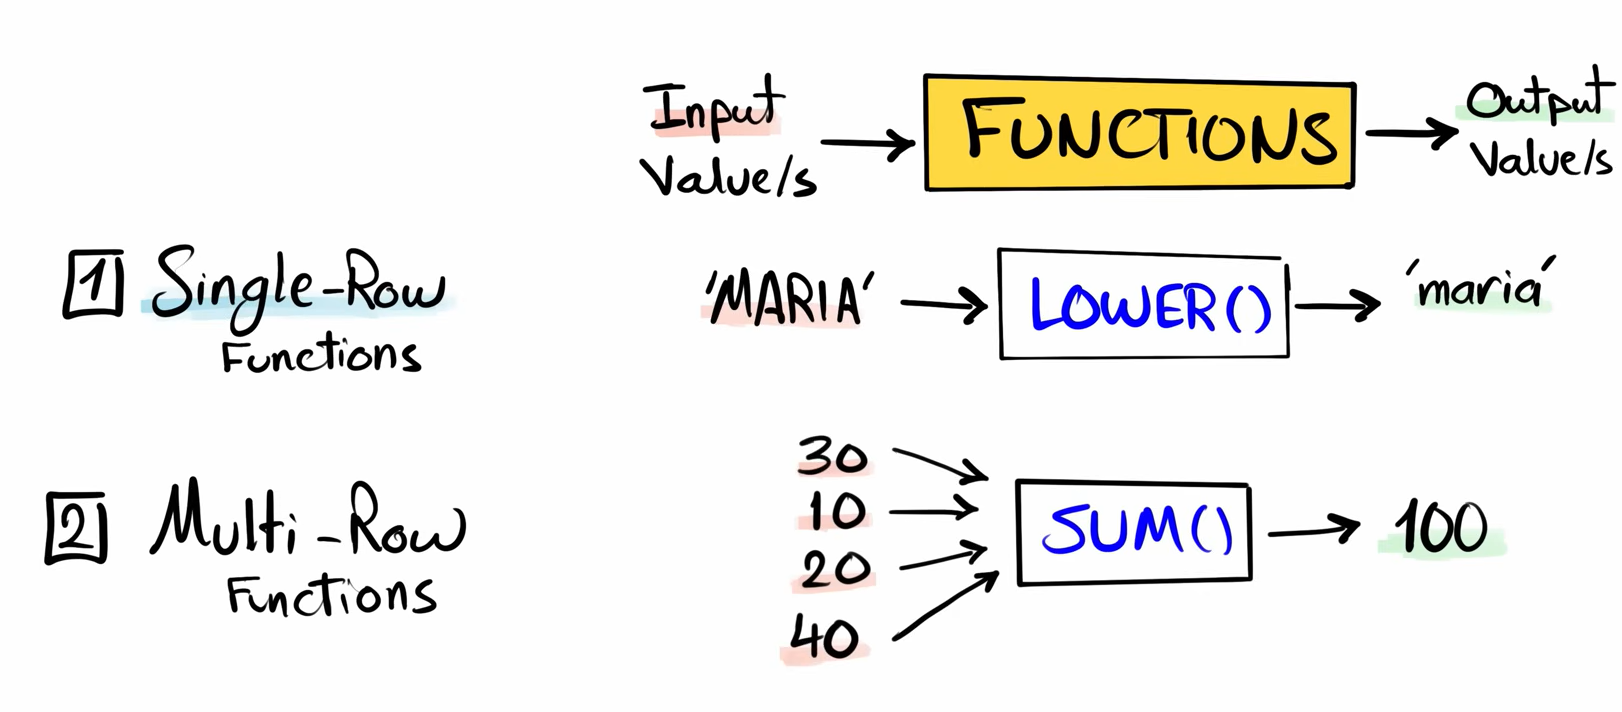

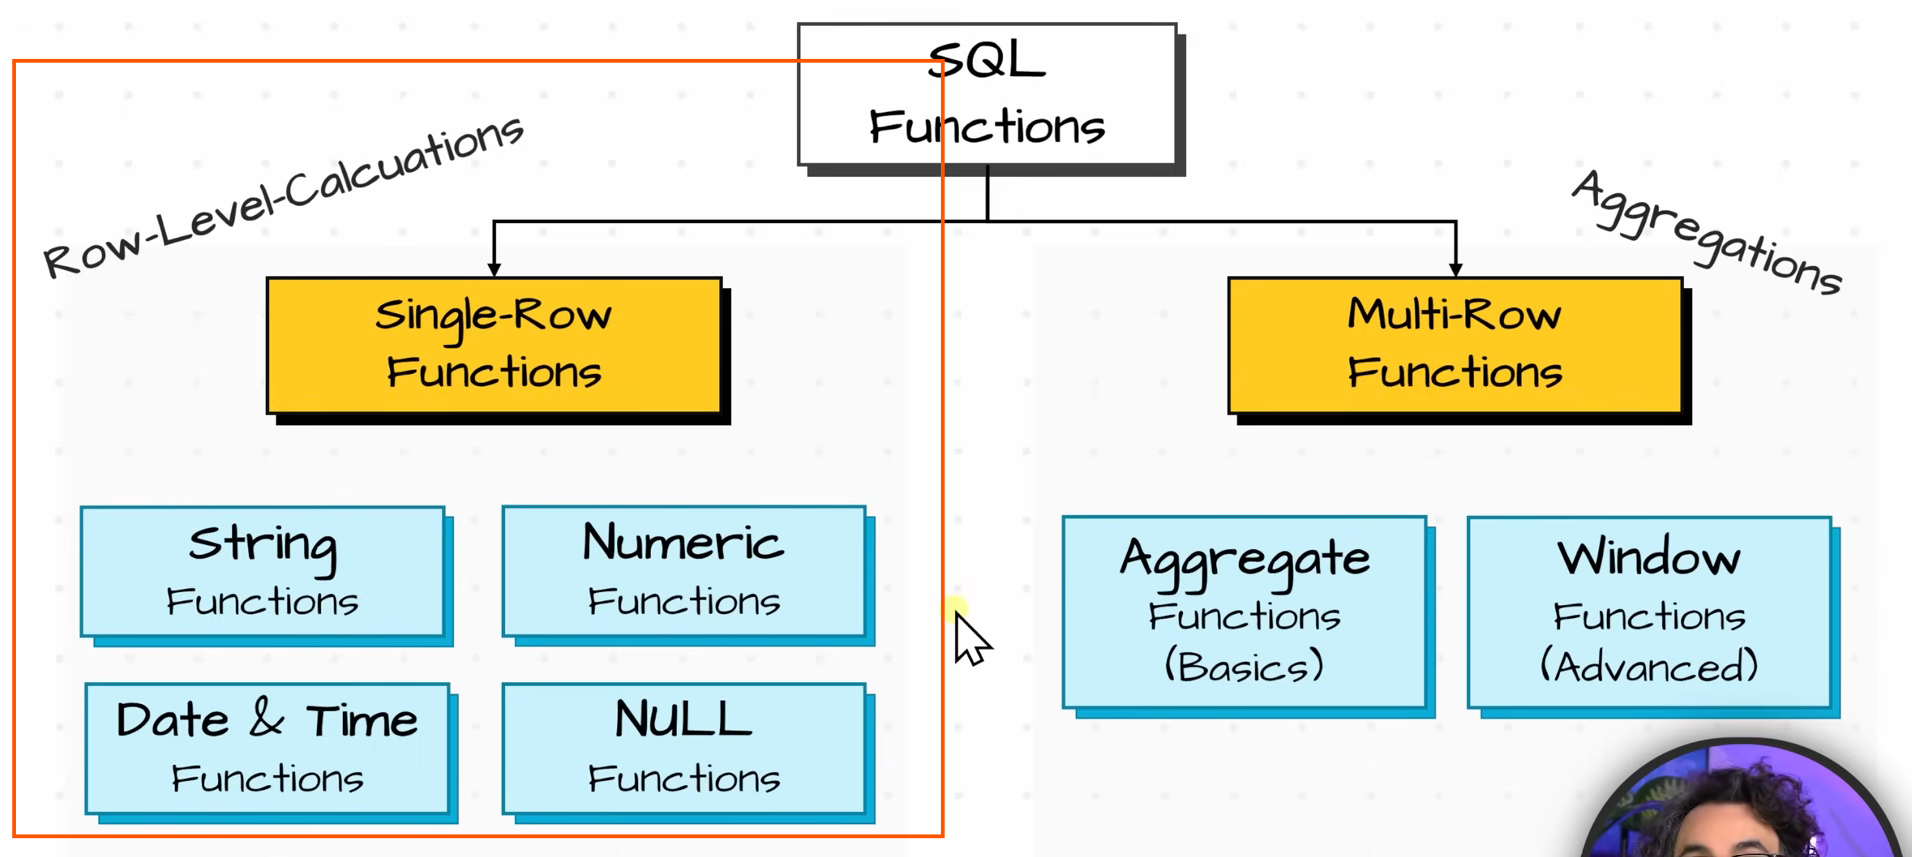

# Nested Function : Function used inside another function

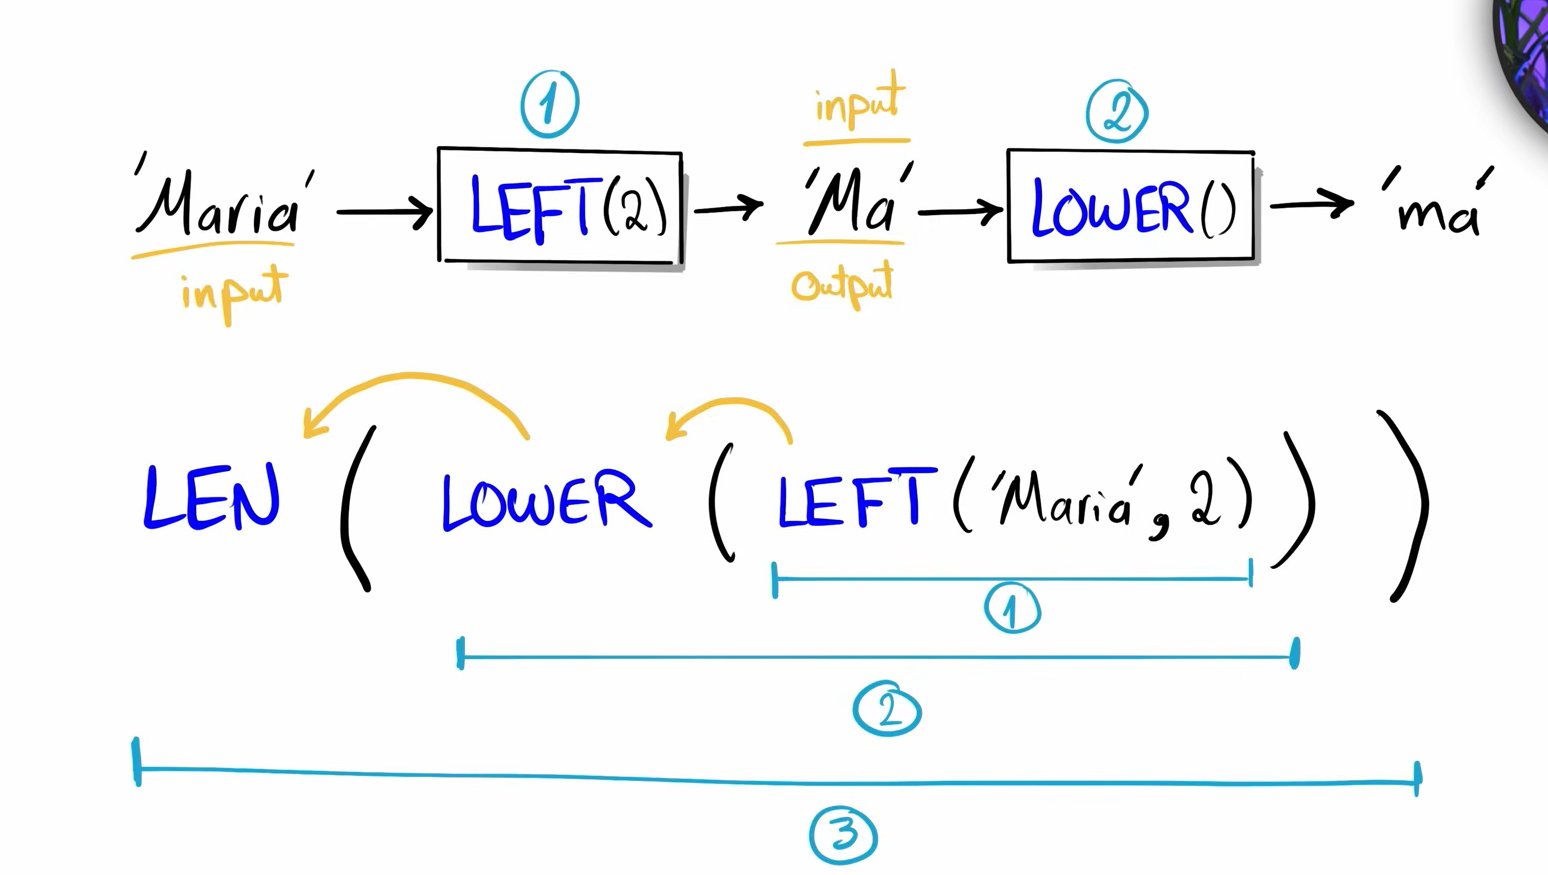

# Types of Functions

```
1. STRING FUNCTIONS : CONCAT, UPPER, LOWER, TRIM, REPLACE, LEN/LENGTH, LEFT, RIGHT, SUBSTRING
2. NUMBER FUNCTIONS : ROUND, ABS
3. DATE & TIME FUNCTIONS : 
4. NULL FUNCTIONS : 
5. CASE STATEMENT : 
```

## STRING FUNCTIONS : 

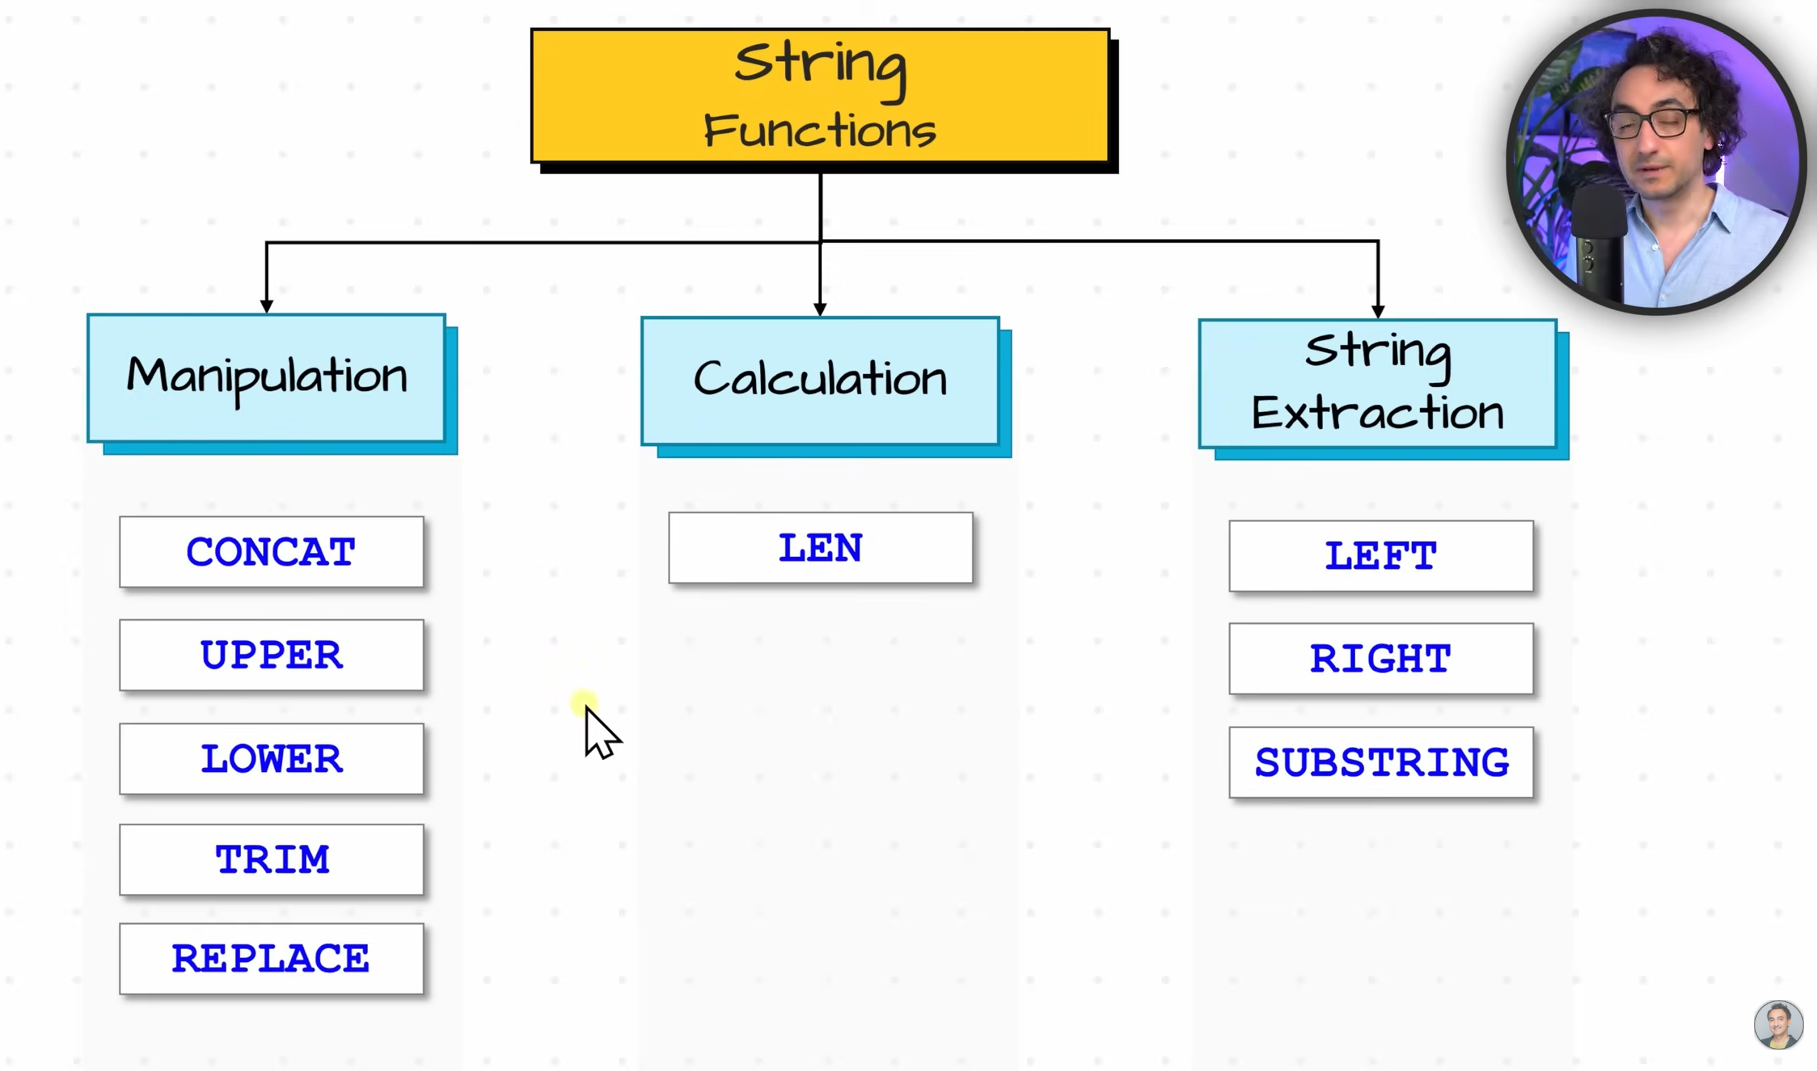

### CONCAT : Combine multiple string value in single string

#### Syntax : 
```
CONCAT('v1', 'v2', 'v3')
v1 can be value or column
```

#### Show the list of customers, concatenate first name and country into one column

In [7]:
%%sql
select concat(firstname, ' : ', country) as 'Name & Country' from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

Name & Country
Jossef : Germany
Kevin : USA
Mary : USA
Mark : Germany
Anna : USA


### UPPER & LOWER : 
```
UPPER : converts all characters to UPPERCASE
LOWER : converts all characters to LOWERCASE
```

#### Syntax :
```
UPPER('column/value')
LOWER('column/value')
```

#### Transform the customer's first name to lower case

In [2]:
%%sql
select firstname,
    lower(firstname) as SmallerFirstName
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

firstname,SmallerFirstName
Jossef,jossef
Kevin,kevin
Mary,mary
Mark,mark
Anna,anna


#### Converts the first name into UPPER case.

In [3]:
%%sql
select firstname, UPPER(firstname) as CapitalFirstName from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

firstname,CapitalFirstName
Jossef,JOSSEF
Kevin,KEVIN
Mary,MARY
Mark,MARK
Anna,ANNA


### TRIM : Removes leading (as prefix) and traiing(as suffix) spaces from string value

#### Syntax :
```
TRIM('value/column')
```

#### Find customers whose first name contains leading and trailing spaces.

In [5]:
%%sql
use MyDatabase;

Running query in 'mysql+pymysql://'

++
||
++
++

##### Method 1:

In [10]:
%%sql
select first_name
from customers
where first_name != TRIM(first_name);

Running query in 'mysql+pymysql://'

1 rows affected.

first_name
John


##### Method 2:

In [20]:
%%sql
select first_name,
    length(first_name) as len_before,
    length(trim(first_name)) as len_after,
    (length(first_name) - length(trim(first_name))) as spaces
from customers;
-- where length(first_name) != length(trim(first_name));

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,len_before,len_after,spaces
Maria,5,5,0
John,5,4,1
Georg,5,5,0
Martin,6,6,0
Peter,5,5,0


##### Method 3:

In [31]:
%%sql
select first_name
from customers
where first_name like '% '
    or first_name like ' %';

Running query in 'mysql+pymysql://'

1 rows affected.

first_name
John


### REPLACE : 
```
1. Replaces specific character with new character
2. Also works as REMOVE where you have to put new character value as empty
```

#### Syntax : 
```
REPLACE('value/column', 'old_replacing_value', 'new_replacement_value')
```

#### Remove dashes(-) from the given phone number : 123-456-7890

In [44]:
%%sql
select '123-456-7890' as phone_number,
replace ('123-456-7890', '-', ':') as updated_phone_number_REPLACED_,
replace ('123-456-7890', '-', '') as clean_phone_number_REMOVED_;

Running query in 'mysql+pymysql://'

1 rows affected.

phone_number,updated_phone_number_REPLACED_,clean_phone_number_REMOVED_
123-456-7890,123:456:7890,1234567890


#### Change the file extension of excel file instead of saved as txt files

In [45]:
%%sql
select 'report.txt' as old_file_name,
    replace('report.txt', '.txt', '.csv') as new_file_name;

Running query in 'mysql+pymysql://'

1 rows affected.

old_file_name,new_file_name
report.txt,report.csv


### LEN or LENGTH : Count the number of character in the value(string/int/date)

#### Syntax :
```
len('column/value')
length('column/value')
```

In [52]:
%%sql
select first_name, length(first_name), score, length(score) from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,length(first_name),score,length(score)
Maria,5,350,3
John,5,900,3
Georg,5,750,3
Martin,6,500,3
Peter,5,0,1


In [56]:
%%sql
select '2026-02-12' as Date, length('2026-02-12') as date_length;

Running query in 'mysql+pymysql://'

1 rows affected.

Date,date_length
2026-02-12,10


### LEFT & RIGHT :
```
1. String Extraction function.
2. LEFT : Extracts specific number of characters from the starts
3. RIGHT : Extracts specific number of characters from the end or last 
```

#### Syntax :
```
LEFT : LEFT('value/column', no._of_characters_from_start)
RIGHT : RIGHT('value/column', no._of_characters_from_END)
```

#### Retrieve the first two character from first name of each customers.

In [60]:
%%sql
select first_name,
    left(trim(first_name), 2) as fist_2_char
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,fist_2_char
Maria,Ma
John,Jo
Georg,Ge
Martin,Ma
Peter,Pe


#### Retrieve the last two character of first name of each customers.

In [63]:
%%sql
select first_name,
    right(first_name, 2) as last_2_char
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,last_2_char
Maria,ia
John,hn
Georg,rg
Martin,in
Peter,er


### SUBSTRING : Extract a part of string at a specified position

#### Syntax : 
```
SUBSTRING('string/value', start_position, end position)
```

#### Retrieve a list of customer's first name after removing the first character.

In [68]:
%%sql
select first_name,
    substring(trim(first_name), 2) as without_first_char
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,without_first_char
Maria,aria
John,ohn
Georg,eorg
Martin,artin
Peter,eter


## NUMERIC FUNCTIONS :

### ROUND Function : It round the number 

#### Syntax :
```
ROUND('number/value/column', rounding_decimal_place)
```

#### Round the number 3.516 till 2 decimal place, 1 decimal place, 0 decimal place

In [69]:
%%sql
select 3.516 as number,
    round(3.516, 2) as round_2,
    round(3.516, 1) as round_1,
    round(3.516) as round_0;

Running query in 'mysql+pymysql://'

1 rows affected.

number,round_2,round_1,round_0
3.516,3.52,3.5,4


### ABS (Absolute) Function : returns the positive(absolute) value of the number, removing any negative sign

#### Syntax :
```
ABS(value/column)
```

#### convert the -10 in positive.

In [70]:
%%sql
select -10 as number,
    ABS(-10) as positive_number;

Running query in 'mysql+pymysql://'

1 rows affected.

number,positive_number
-10,10


#### What will be absolute of 33?

In [71]:
%%sql
select 33 as number,
    ABS(33) as ABS_OF_33;

Running query in 'mysql+pymysql://'

1 rows affected.

number,ABS_OF_33
33,33


## DATE & TIME FUNCTIONS : 

### Datetime or Timestamp

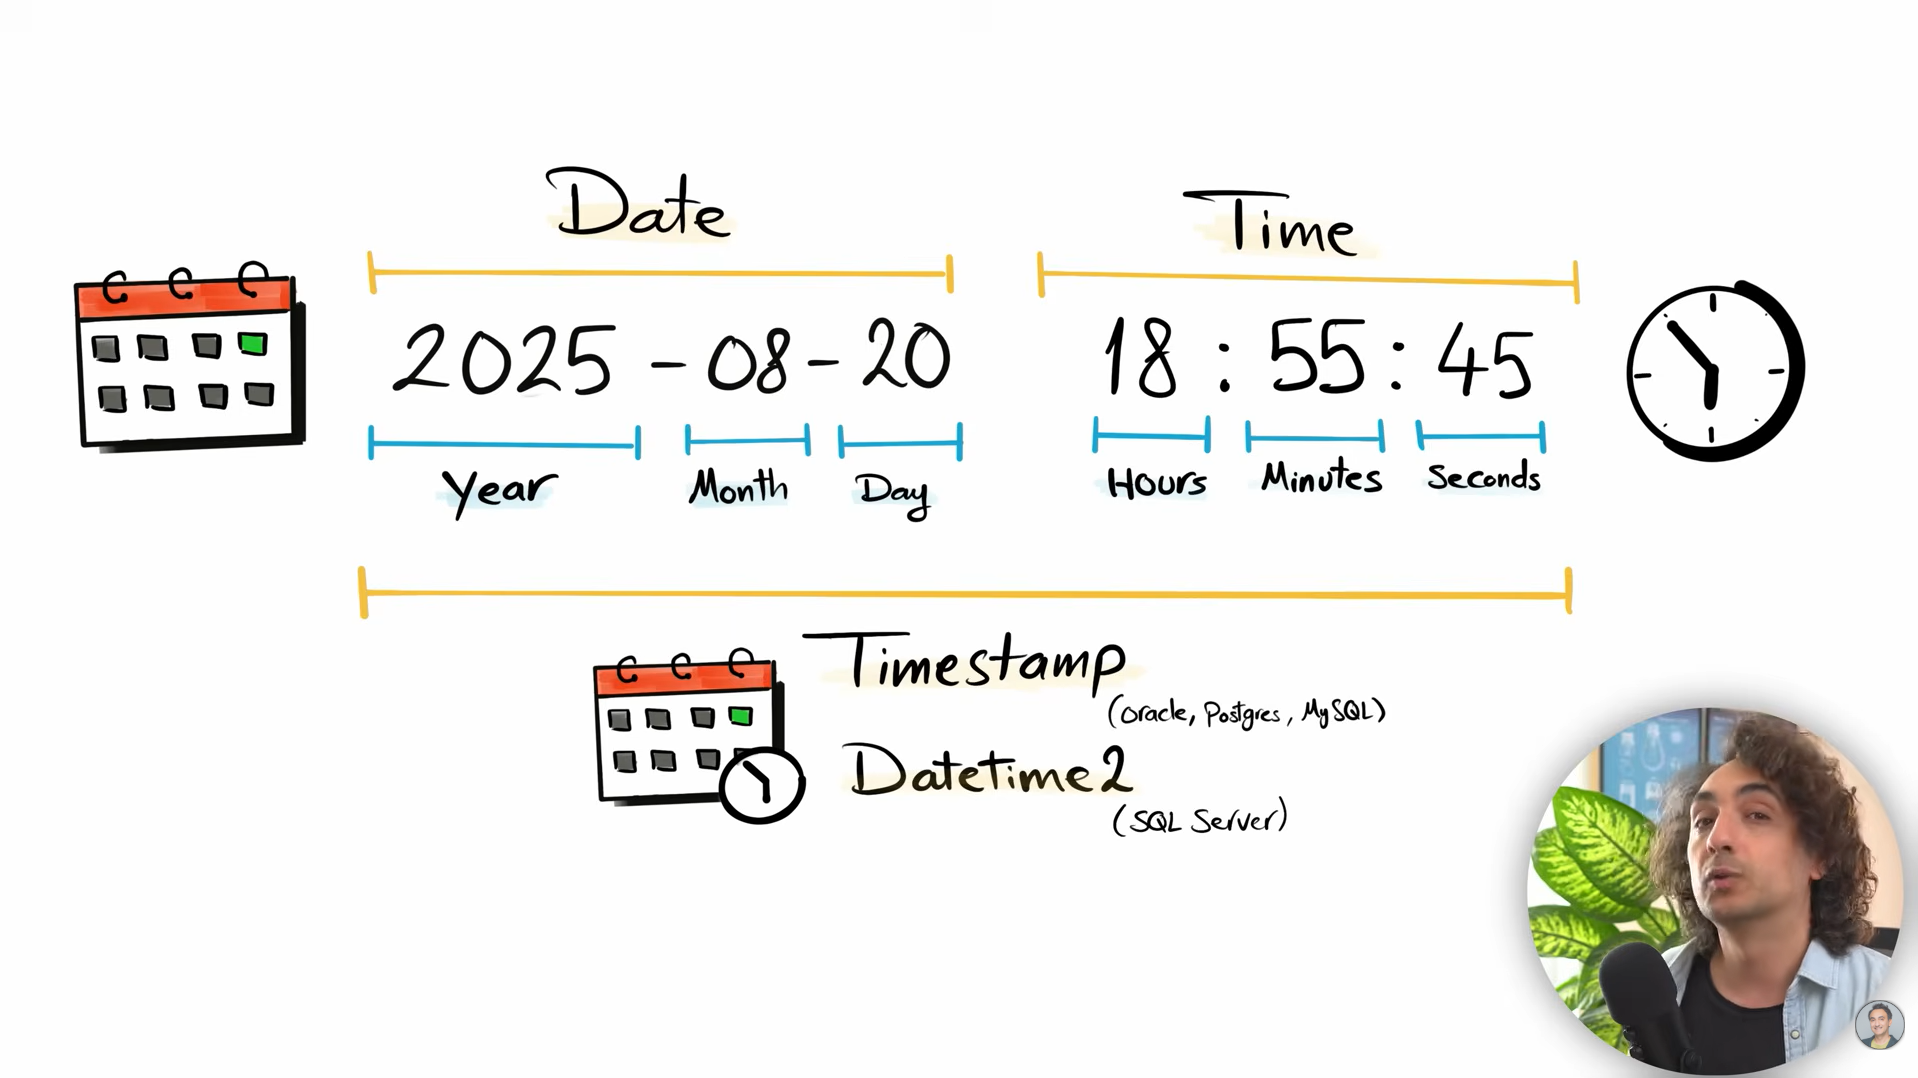

### Syntax : 
```
1. now() / getdate()
2. DATE_ADD()
3. DATE_ADD(now(), INTERVAL '5:30' HOUR MINUTE)  -- to add time in time to update zone or etc..
4. DAY(date)
5. MONTH(date)
6. YEAR(date)
7. DATEPART(part, date) : It extract the date part of the date like (Year, Quarter, Month, Week, Hours, Minutes, Seconds) (Oracle/PostgreSQL)
 . EXTRACT(part from date) : same as DATEPART : Extract many things from this keyword or function
8. DATENAME(part, date) {MONTHNAME(date), DAYNAME(date)} : Returns the name to a datepart
9. DATETRUNC(part, date) {DATE_FORMAT(date, '%Y-%m-%d %H-%i-%s')} : reset the level of timestamp
10. EOMONTH(date) {LAST_DAY(date)}: Returns the last day of the month
```

### Source of DATE value:

```
1. Column Date Data : It is from any table
1. HARD CODED Date Data : It is a static value
3. NOW()(MySQL)/GETDATE()(Oracle/MSSQL/etc..) : Returns the current date and time at the moment when the query is executed
```

#### Example :

In [84]:
%%sql
select orderdate as TableDate_orderdate,
    '2022-08-12' as HardCodedDate,
    now() as todayGMT,
    DATE_ADD(now(), INTERVAL '5:30' HOUR_MINUTE) as todayIST
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

TableDate_orderdate,HardCodedDate,todayGMT,todayIST
2025-01-01,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-01-05,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-01-10,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-01-20,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-01,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-05,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-15,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-18,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-03-10,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-03-15,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22


### Date & Time Function Overview : 

#### Part Extraction : (DAY, MONTH, YEAR, DATEPART / EXTRACT, DATENAME, DATETRUNC, EOMONTH)

##### DAY, MONTH, YEAR

```
DAY() : returns the DAY from a date
MONTH() : returns the MONTH from a date
YEAR() : returns the YEAR from a date
```

In [4]:
%%sql
select orderid,
    creationtime,
    year(creationtime) as Year,
    month(creationtime) as Month,
    day(creationtime) as Day
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Year,Month,Day
1,2025-01-01 12:34:56,2025,1,1
2,2025-01-05 23:22:04,2025,1,5
3,2025-01-10 18:24:08,2025,1,10
4,2025-01-20 05:50:33,2025,1,20
5,2025-02-01 14:02:41,2025,2,1
6,2025-02-06 15:34:57,2025,2,6
7,2025-02-16 06:22:01,2025,2,16
8,2025-02-18 10:45:22,2025,2,18
9,2025-03-10 12:59:04,2025,3,10
10,2025-03-16 23:25:15,2025,3,16


##### DATEPART / EXTRACT

```
DATEPART(Year, date)
EXTRACT(Year from date)
```

In [21]:
%%sql
SELECT orderid,
    creationtime,
    Extract(
        Year
        from creationtime
    ) AS Year,
    EXTRACT(
        Quarter
        from creationtime
    ) as Quarter,
    Extract(
        Week
        from creationtime
    ) as Week,
    Extract(
        Month
        from creationtime
    ) as Month,
    Extract(
        Day
        from creationtime
    ) as Day,
    Extract(
        Hour
        from creationtime
    ) as Hour,
    Extract(
        Minute
        from creationtime
    ) as Minutes,
    Extract(
        second
        from creationtime
    ) as Seconds
FROM orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Year,Quarter,Week,Month,Day,Hour,Minutes,Seconds
1,2025-01-01 12:34:56,2025,1,0,1,1,12,34,56
2,2025-01-05 23:22:04,2025,1,1,1,5,23,22,4
3,2025-01-10 18:24:08,2025,1,1,1,10,18,24,8
4,2025-01-20 05:50:33,2025,1,3,1,20,5,50,33
5,2025-02-01 14:02:41,2025,1,4,2,1,14,2,41
6,2025-02-06 15:34:57,2025,1,5,2,6,15,34,57
7,2025-02-16 06:22:01,2025,1,7,2,16,6,22,1
8,2025-02-18 10:45:22,2025,1,7,2,18,10,45,22
9,2025-03-10 12:59:04,2025,1,10,3,10,12,59,4
10,2025-03-16 23:25:15,2025,1,11,3,16,23,25,15


##### DATENAME , MONTHNAME, DAYNAME

```
DATENAME(part, date) : MONTHNAME(date) : DAYNAME(date)
```

In [30]:
%%sql
select orderid,
    creationtime,
    MONTHNAME(creationtime) as Month,
    DAYNAME(creationtime) as Day
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Month,Day
1,2025-01-01 12:34:56,January,Wednesday
2,2025-01-05 23:22:04,January,Sunday
3,2025-01-10 18:24:08,January,Friday
4,2025-01-20 05:50:33,January,Monday
5,2025-02-01 14:02:41,February,Saturday
6,2025-02-06 15:34:57,February,Thursday
7,2025-02-16 06:22:01,February,Sunday
8,2025-02-18 10:45:22,February,Tuesday
9,2025-03-10 12:59:04,March,Monday
10,2025-03-16 23:25:15,March,Sunday


##### DATETRUNC / DATE_FORMAT

```
DATETRUNC(part, date) : reset to 1(datepart), 0(timepart) below all thing the part
DATE(date) : full date
DTAE-FORMAT(date, '%y-01-01') : returns as year-01-01 : month and date both reset to 01 and time get reset to 0
DATE_FORMAT(date, '%y-%m-01') : returns as year-month-01 : date reset to 01 and time get reset to 0
DATE_FORMAT(date, '%y-%m-%d') : returns year-month-date : time get reset to 0
DATE_FORMAT(date, '%y-%m-%d %H:00:00') : returns till hours and minutes and seconds get reset
DATE_FORMAT(date, '%y-%m-%d %H:%i:00') : returns till minutes and seconds get reset to 0
DATE_FORMAT(date, '%y-%m-%d %H:%i:%s') : returns full timestamp
```

In [57]:
%%sql
select orderid, creationtime,
date(creationtime) as FullDate,
time(creationtime) as FullTime,
date_format(creationtime, '%Y-%m-%d %H:%i:%s') as Timestamp,
date_format(creationtime, '%Y-%m-%d %H:%i:00') as SecondReset,
date_format(creationtime, '%Y-%m-%d %H:00:00') as MinuteReset,
date_format(creationtime, '%Y-%m-%d 00:00:00') as HourReset,
date_format(creationtime, '%Y-%m-00 00:00:00') as DateReset,
date_format(creationtime, '%Y-00-00 00:00:00') as MonthReset,
date_format(creationtime, '00-00-00 00:00:00') as TimestampReset
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,FullDate,FullTime,Timestamp,SecondReset,MinuteReset,HourReset,DateReset,MonthReset,TimestampReset
1,2025-01-01 12:34:56,2025-01-01,12:34:56,2025-01-01 12:34:56,2025-01-01 12:34:00,2025-01-01 12:00:00,2025-01-01 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
2,2025-01-05 23:22:04,2025-01-05,23:22:04,2025-01-05 23:22:04,2025-01-05 23:22:00,2025-01-05 23:00:00,2025-01-05 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
3,2025-01-10 18:24:08,2025-01-10,18:24:08,2025-01-10 18:24:08,2025-01-10 18:24:00,2025-01-10 18:00:00,2025-01-10 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
4,2025-01-20 05:50:33,2025-01-20,5:50:33,2025-01-20 05:50:33,2025-01-20 05:50:00,2025-01-20 05:00:00,2025-01-20 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
5,2025-02-01 14:02:41,2025-02-01,14:02:41,2025-02-01 14:02:41,2025-02-01 14:02:00,2025-02-01 14:00:00,2025-02-01 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
6,2025-02-06 15:34:57,2025-02-06,15:34:57,2025-02-06 15:34:57,2025-02-06 15:34:00,2025-02-06 15:00:00,2025-02-06 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
7,2025-02-16 06:22:01,2025-02-16,6:22:01,2025-02-16 06:22:01,2025-02-16 06:22:00,2025-02-16 06:00:00,2025-02-16 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
8,2025-02-18 10:45:22,2025-02-18,10:45:22,2025-02-18 10:45:22,2025-02-18 10:45:00,2025-02-18 10:00:00,2025-02-18 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
9,2025-03-10 12:59:04,2025-03-10,12:59:04,2025-03-10 12:59:04,2025-03-10 12:59:00,2025-03-10 12:00:00,2025-03-10 00:00:00,2025-03-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
10,2025-03-16 23:25:15,2025-03-16,23:25:15,2025-03-16 23:25:15,2025-03-16 23:25:00,2025-03-16 23:00:00,2025-03-16 00:00:00,2025-03-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00


In [68]:
%%sql
select orderid, creationtime, date_format(creationtime, '%y-%m-%d') as Date, 
date_format(creationtime, '%Y-%m-%d') as YearDate,
date_format(creationtime, '%Y-%M-%d') as MonthDate,
date_format(creationtime, '%Y-%M-%D') as DayDate
 from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Date,YearDate,MonthDate,DayDate
1,2025-01-01 12:34:56,25-01-01,2025-01-01,2025-January-01,2025-January-1st
2,2025-01-05 23:22:04,25-01-05,2025-01-05,2025-January-05,2025-January-5th
3,2025-01-10 18:24:08,25-01-10,2025-01-10,2025-January-10,2025-January-10th
4,2025-01-20 05:50:33,25-01-20,2025-01-20,2025-January-20,2025-January-20th
5,2025-02-01 14:02:41,25-02-01,2025-02-01,2025-February-01,2025-February-1st
6,2025-02-06 15:34:57,25-02-06,2025-02-06,2025-February-06,2025-February-6th
7,2025-02-16 06:22:01,25-02-16,2025-02-16,2025-February-16,2025-February-16th
8,2025-02-18 10:45:22,25-02-18,2025-02-18,2025-February-18,2025-February-18th
9,2025-03-10 12:59:04,25-03-10,2025-03-10,2025-March-10,2025-March-10th
10,2025-03-16 23:25:15,25-03-16,2025-03-16,2025-March-16,2025-March-16th


##### Why DATETRUNC or DATE_FORMAT is very useful in Data Analysis?

###### Count at highest granuality.

In [3]:
%%sql
select creationtime, count(*) from orders group by creationtime;

Running query in 'mysql+pymysql://'

10 rows affected.

creationtime,count(*)
2025-01-01 12:34:56,1
2025-01-05 23:22:04,1
2025-01-10 18:24:08,1
2025-01-20 05:50:33,1
2025-02-01 14:02:41,1
2025-02-06 15:34:57,1
2025-02-16 06:22:01,1
2025-02-18 10:45:22,1
2025-03-10 12:59:04,1
2025-03-16 23:25:15,1


###### Count at Month granuality

In [14]:
%%sql
select date_format(creationtime, '%Y-%m-01') as CreationTime_Month,
    count(*) as Count
from orders
group by date_format(creationtime, '%Y-%m-01');

Running query in 'mysql+pymysql://'

3 rows affected.

CreationTime_Month,Count
2025-01-01,4
2025-02-01,4
2025-03-01,2


##### EOMONTH / LAST_DAY: EOMONTH(date) / LAST_DAY(date): returns last day of month : date

In [18]:
%%sql
select LAST_DAY('2026-08-04') as LastDate;

Running query in 'mysql+pymysql://'

1 rows affected.

LastDate
2026-08-31


In [23]:
%%sql
select orderid,
    creationtime,
    concat(last_day(creationtime), ' ', time(creationtime)) as LastDate
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,LastDate
1,2025-01-01 12:34:56,2025-01-31 12:34:56
2,2025-01-05 23:22:04,2025-01-31 23:22:04
3,2025-01-10 18:24:08,2025-01-31 18:24:08
4,2025-01-20 05:50:33,2025-01-31 05:50:33
5,2025-02-01 14:02:41,2025-02-28 14:02:41
6,2025-02-06 15:34:57,2025-02-28 15:34:57
7,2025-02-16 06:22:01,2025-02-28 06:22:01
8,2025-02-18 10:45:22,2025-02-28 10:45:22
9,2025-03-10 12:59:04,2025-03-31 12:59:04
10,2025-03-16 23:25:15,2025-03-31 23:25:15


#### Format Manipulation : (FORMAT, CONVERT, CAST)

#### Calculation on Dates : (DATE_ADD, DATEADD, DATEDIFF)

#### Date Validation : ISDATE : Only return boolean value either TRUE or FALSE

In [1]:
%%sql
use salesdb;

Running query in 'mysql+pymysql://'

++
||
++
++

In [76]:
%%sql
select orderdate,
    shipdate,
    creationtime
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderdate,shipdate,creationtime
2025-01-01,2025-01-05,2025-01-01 12:34:56
2025-01-05,2025-01-10,2025-01-05 23:22:04
2025-01-10,2025-01-25,2025-01-10 18:24:08
2025-01-20,2025-01-25,2025-01-20 05:50:33
2025-02-01,2025-02-05,2025-02-01 14:02:41
2025-02-05,2025-02-10,2025-02-06 15:34:57
2025-02-15,2025-02-27,2025-02-16 06:22:01
2025-02-18,2025-02-27,2025-02-18 10:45:22
2025-03-10,2025-03-15,2025-03-10 12:59:04
2025-03-15,2025-03-20,2025-03-16 23:25:15


####